In [6]:
# Dados
import pandas as pd 
import numpy as np 

# Visualização
import seaborn as sns
import matplotlib
from matplotlib import pyplot as plt

# Persistência (salvar/carregar modelos/pipelines)
import joblib

# Pipelines e transformações
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import FunctionTransformer, StandardScaler, PolynomialFeatures
from sklearn.impute import SimpleImputer

# Seleção de features (com CV)
from sklearn.feature_selection import RFECV

# Validação cruzada
from sklearn.model_selection import KFold, cross_validate

# Métricas
from sklearn.metrics import make_scorer, r2_score, mean_squared_error, mean_absolute_error

# Modelos
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

# Transformer customizado (definido no seu projeto)
from Utils.transformers import LogTransformer

# Logging (silencia mensagens não críticas)
import logging
logging.getLogger().setLevel(logging.CRITICAL)

import warnings
warnings.filterwarnings("ignore")


### 04 - Avaliação de Métrica

In [7]:
# Carrega dataset de treino
df_train = pd.read_csv('./Data/train.csv')
X_train = df_train.drop(columns=['MEDV'])  # features
y_train = df_train['MEDV']                 # alvo

# Carrega dataset de teste
df_test = pd.read_csv('./Data/test.csv')
X_test = df_test.drop(columns=['MEDV'])
y_test = df_test['MEDV']

# Carrega lista de colunas usadas no treino
with open("./Data/X_train_columns.txt", "r") as f:
    saved_columns = [line.strip() for line in f.readlines()]

# Carrega pipeline já treinada (pré-processamento + modelo)
pipe_modelo = joblib.load("./Utils/pipeline_modelo.pkl")


### Métricas:

Nesse projeto avaliamos as seguintes métricas:
- R2: Média a porcentagem de variância explicada pelo modelo.
- MSE: Erro Médio Quadrático, pode ser visto como uma estimação da variância do estimador.
- MAE: Erro Médio Absoluto, pode ser visto como uma estimação do desvio padrão do estimador.

In [8]:
# Pipeline do modelo
pipe_modelo

,steps,"[('pipe_loaded', ...), ('rfe', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('imputer', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'median'
,fill_value,None


In [9]:
y_pred = pipe_modelo.predict(X_test[saved_columns])

# Avaliação das métricas
metrics = {
    'R_2 (Test)': r2_score(y_test, y_pred),
    'MSE (Test)': mean_squared_error(y_test, y_pred),
    'MAE (Test)': mean_absolute_error(y_test, y_pred)
}

# Organizando no formato linha → métrica, coluna → valor
results = pd.DataFrame([metrics]).round(2)
results

,R_2 (Test),MSE (Test),MAE (Test)
0,0.8,18.17,2.65


### Sensibilidade em relação às features

In [10]:
from sklearn.inspection import permutation_importance

# Calcula importância por permutação (métrica = R², repetido 30 vezes)
result = permutation_importance(
    pipe_modelo, 
    X_test[saved_columns], 
    y_test, 
    scoring='r2', 
    n_repeats=30, 
    random_state=42
)

# Organiza em DataFrame: média e desvio padrão
importances = pd.DataFrame({
    "feature": saved_columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
}).sort_values(by="importance_mean", ascending=False)

# Exibe importâncias
importances


,feature,importance_mean,importance_std
0,RM,0.572384,0.080198
1,LSTAT,0.367273,0.074526
2,PTRATIO,0.033662,0.017541
3,RAD,0.021169,0.011116


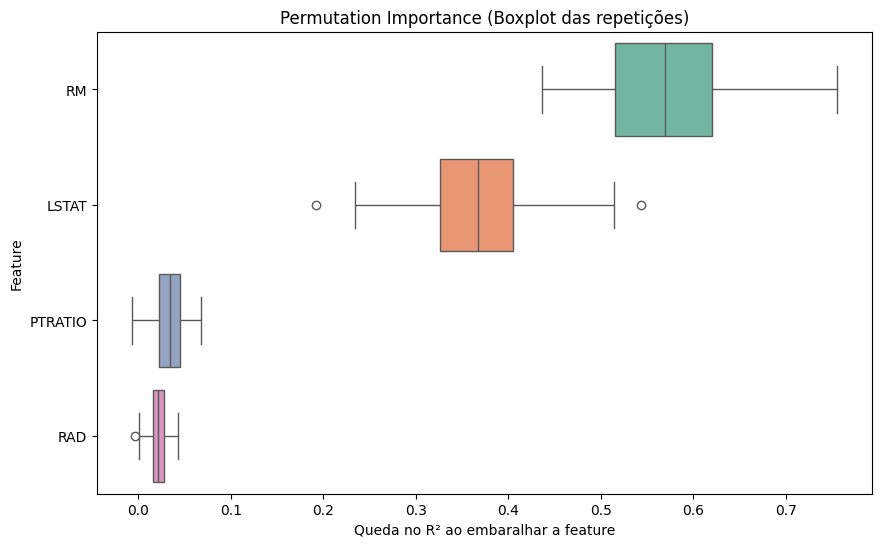

In [11]:
# Converte importâncias para formato longo (cada repetição como uma linha)
df_long = pd.DataFrame(result.importances.T, columns=saved_columns)
df_long = df_long.melt(var_name="feature", value_name="importance")

# Ordena features pelo ranking médio
order = importances["feature"]

# Boxplot das importâncias (variação entre repetições)
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_long, 
    x="importance", 
    y="feature", 
    order=order, 
    orient="h", 
    palette="Set2"
)
plt.title("Permutation Importance (Boxplot das repetições)")
plt.xlabel("Queda no R² ao embaralhar a feature")
plt.ylabel("Feature")
plt.show()


### Estabilidade de métricas (Sensibilidade global)

In [12]:
from sklearn.model_selection import cross_validate, KFold
import numpy as np

# Esquema de validação cruzada (5 folds, embaralhando dados)
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Métricas a avaliar
scoring = ['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error']

# Executa CV com múltiplas métricas
results = cross_validate(pipe_modelo, X_test[saved_columns], y_test, cv=cv, scoring=scoring)

# Agrega resultados (lembrando que MSE/MAE vêm negativos no sklearn)
print("R² médio:", np.mean(results['test_r2']))
print("R² desvio-padrão:", np.std(results['test_r2']))
print("MSE médio:", -np.mean(results['test_neg_mean_squared_error']))
print("MAE médio:", -np.mean(results['test_neg_mean_absolute_error']))


R² médio: 0.7356289123854317
R² desvio-padrão: 0.09554552563410944
MSE médio: 24.055530797285638
MAE médio: 3.2795191364495295


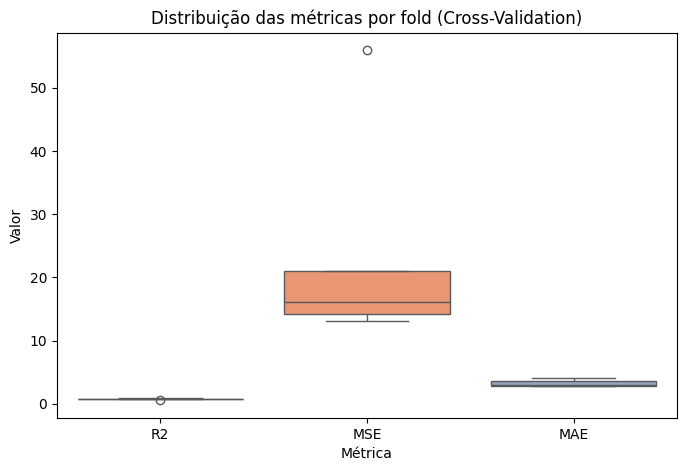

In [13]:
# Organiza métricas por fold em DataFrame
df_results = pd.DataFrame({
    "R2": results['test_r2'],
    "MSE": -results['test_neg_mean_squared_error'],
    "MAE": -results['test_neg_mean_absolute_error']
})

# Converte para formato longo (métricas empilhadas)
df_long = df_results.melt(var_name="Métrica", value_name="Valor")

# Boxplot das métricas
plt.figure(figsize=(8,5))
sns.boxplot(data=df_long, x="Métrica", y="Valor", palette="Set2")
plt.title("Distribuição das métricas por fold (Cross-Validation)")
plt.show()


O modelo é razoavelmente estável, mas o desvio de 0.11 no R² indica que ele é sensível à forma como os dados são divididos. Como o MSE tem escala muito maior, ele “espreme” o R² e o MAE quase no zero, logo para melhorar a interpretabilidade dos resultados optamos por padronizar as métricas antes de realizar o boxplot

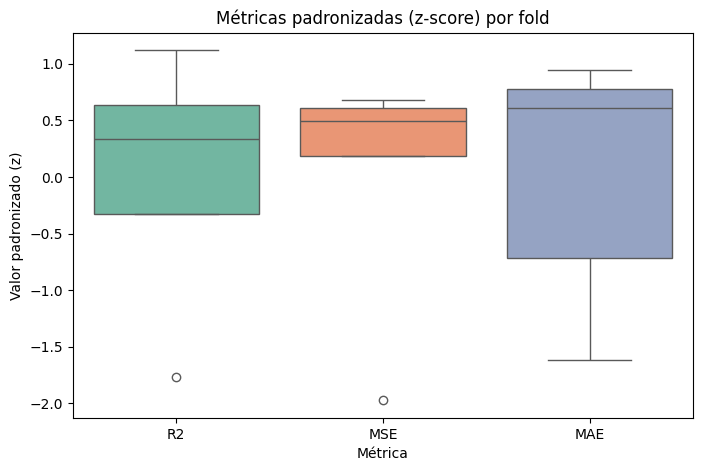

In [14]:
# Corrige sinal para que maiores = melhor
df_results["MSE_score"] = -df_results["MSE"]
df_results["MAE_score"] = -df_results["MAE"]

# Mantém apenas métricas no formato "score"
df_scores = df_results[["R2", "MSE_score", "MAE_score"]].rename(
    columns={"MSE_score": "MSE", "MAE_score": "MAE"}
)

# Padroniza em z-score (média=0, desvio=1) para comparar escalas
df_z = (df_scores - df_scores.mean()) / df_scores.std(ddof=0)

# Formato longo para plotagem
df_long = df_z.melt(var_name="Métrica", value_name="Valor padronizado (z)")

# Boxplot comparando métricas já normalizadas
plt.figure(figsize=(8,5))
sns.boxplot(data=df_long, x="Métrica", y="Valor padronizado (z)", palette="Set2")
plt.title("Métricas padronizadas (z-score) por fold")
plt.show()

O boxplot mostra que o MAE apresenta maior variação entre os folds, indicando maior sensibilidade às divisões dos dados, enquanto MSE e R² score têm distribuições mais compactas, sugerindo erros absolutos mais estáveis; como as métricas foram padronizadas em z-score, caixas estreitas indicam baixa oscilação (maior estabilidade) e caixas largas revelam alta oscilação (maior sensibilidade).

In [15]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
